# Fiberwise Clustering Of $X(50,60)$

In this notebook, we study the filament structure in the dense-core subset
$X(50,60)$ of the high-contrast optical flow patches. We cluster the data
independently over overlapping sets in the predominant-direction cover, join
local clusters across overlaps, and recover the family of step-edge circles
described in the paper.


## Publication-scale analysis

This notebook uses the complete 150,000-point $X(50,60)$ sample and the exact
parameters used for the paper analysis. Several later steps identify particular
components from this dataset, so the notebook intentionally has one canonical
publication-scale workflow rather than a reduced-data mode.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import circle_bundles as cb
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from circle_bundles.analysis.fiberwise_clustering import (
    fiberwise_clustering,
    get_cluster_persistence,
    get_filtered_cluster_graph,
    get_weights,
    plot_fiberwise_pca_grid,
    plot_fiberwise_summary_bars,
)
from circle_bundles.viz.circle_vis import circle_vis, circle_vis_grid
from circle_bundles.viz.fiberwise_clustering_vis import (
    get_G_vertex_coords,
    make_patch_cluster_diagram,
)
from dreimac import CircularCoords

ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent

random_seed = 0
k = 50
p = 0.60
expected_patch_count = 150000
artifact_name = "HC20_Flow_Patches.v1.npz"
n_landmarks = 16
legacy_chord_overlap = 1.49
local_rips_points = 500
component_rips_points = 500
dbscan_epsilon = 0.30
dbscan_min_samples = 5
graph_weight_threshold = 0.07
samples_per_filament = 250

figure_dir = ROOT / "results" / "paper" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
output_paths = {}


def figure_path(paper_name):
    return figure_dir / Path(paper_name).name


print("Running the publication-scale analysis.")


Running the publication-scale analysis.


## Load The Dataset

Load the portable, pickle-free version of the preprocessed high-contrast
sample. Notebook 00 documents the source data and preprocessing; this notebook
begins with the resulting table so the clustering experiment can be rerun
independently.


In [2]:
artifact_path = Path(
    os.environ.get("OPTICAL_FLOW_PREPROCESSED", ROOT / "data" / artifact_name)
).expanduser()
if not artifact_path.is_file():
    raise RuntimeError(f"Preprocessed artifact not found: {artifact_path}")

with np.load(artifact_path, allow_pickle=False) as archive:
    metadata = json.loads(str(archive["metadata_json"].item()))
    columns = {
        name: np.asarray(archive[metadata["key_map"][name]])
        for name in metadata["scalar_columns"]
    }
    patches = np.asarray(archive["patches"])

patch_df = pd.DataFrame(columns)
patch_df.insert(0, "patch", list(patches))

density_column = f"density_{k}"
patch_df = patch_df.sort_values(
    density_column,
    ascending=False,
    kind="mergesort",
).reset_index(drop=True)

n_samples = int(p*len(patch_df))
data = np.vstack(patch_df["patch"])[:n_samples]
assert len(data) == expected_patch_count

predom_dirs, ratios = cb.get_predominant_dirs(data)
patch_vis = cb.make_patch_visualizer()
print(f"X({k}, {int(100*p)}) contains {len(data):,} patches")


X(50, 60) contains 150,000 patches


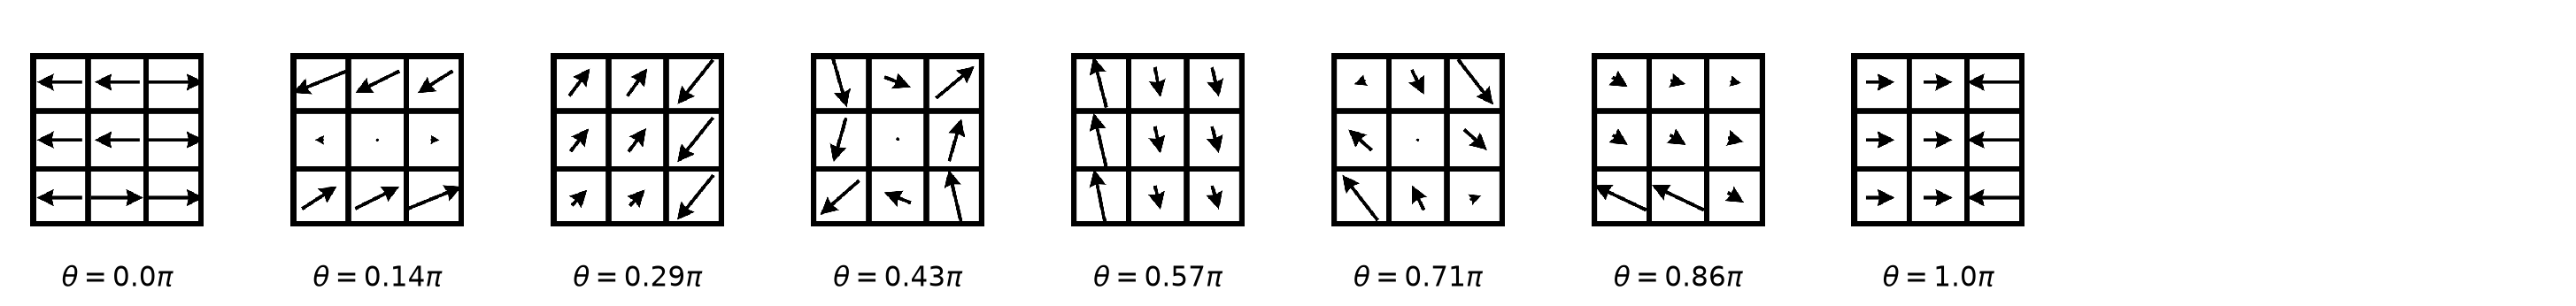

In [3]:
#Show a sample of the data
n_samples = 8
labels = [
    fr"$\theta = {np.round(pred/np.pi, 2)}\pi$"
    for pred in predom_dirs
]
fig, axes = cb.show_data_vis(
    data,
    patch_vis,
    label_func=labels,
    angles=predom_dirs,
    sampling_method="angle",
    max_samples=n_samples,
)
plt.show()


# Bundle Analysis

## Base Projections And Open Cover

The executed legacy notebook constructed Euclidean balls around equally spaced
landmarks on the doubled-angle unit circle and multiplied the data-dependent
covering radius by `1.49`. The next cell reconstructs that cover exactly and
then expresses it through the current `RP1AngleMetric` API. This is slightly
different from simply rounding the new angular overlap to `1.5`.


In [4]:
landmarks = np.linspace(0, np.pi, n_landmarks, endpoint=False)

#Reproduce the old doubled-angle Euclidean cover exactly
base_points = np.column_stack(
    (np.cos(2*predom_dirs), np.sin(2*predom_dirs))
)
doubled_landmark_angles = np.linspace(
    0,
    2*np.pi,
    n_landmarks,
    endpoint=False,
)
doubled_landmarks = np.column_stack(
    (
        np.cos(doubled_landmark_angles),
        np.sin(doubled_landmark_angles),
    )
)
chord_distances = np.linalg.norm(
    doubled_landmarks[:, None, :] - base_points[None, :, :],
    axis=2,
)
legacy_covering_radius = np.max(np.min(chord_distances, axis=0))
legacy_chord_radius = legacy_chord_overlap*legacy_covering_radius
legacy_U = chord_distances < legacy_chord_radius

#A chord of length d on the doubled-angle circle subtends RP1 angle asin(d/2)
radius = np.arcsin(legacy_chord_radius/2)
effective_angular_overlap = radius*2*n_landmarks/np.pi

cover = cb.get_metric_ball_cover(
    predom_dirs.reshape(-1, 1),
    landmarks.reshape(-1, 1),
    radius=radius,
    metric=cb.RP1AngleMetric(),
)
np.testing.assert_array_equal(cover.U, legacy_U)

print(f"Cover radius: {radius:.12f}")
print(f"Equivalent angular overlap: {effective_angular_overlap:.12f}")
print(f"Fiber cardinalities: {cover.U.sum(axis=1).tolist()}")


Cover radius: 0.146569614072
Equivalent angular overlap: 1.492945829545
Fiber cardinalities: [21197, 17176, 16012, 13182, 10117, 8998, 8215, 9278, 15443, 10107, 8945, 10240, 11918, 14161, 22528, 25183]


Saved local PCA figure to /Users/bradturow/Desktop/optical_flow_paper/results/paper/figures/Sample_Projections.pdf


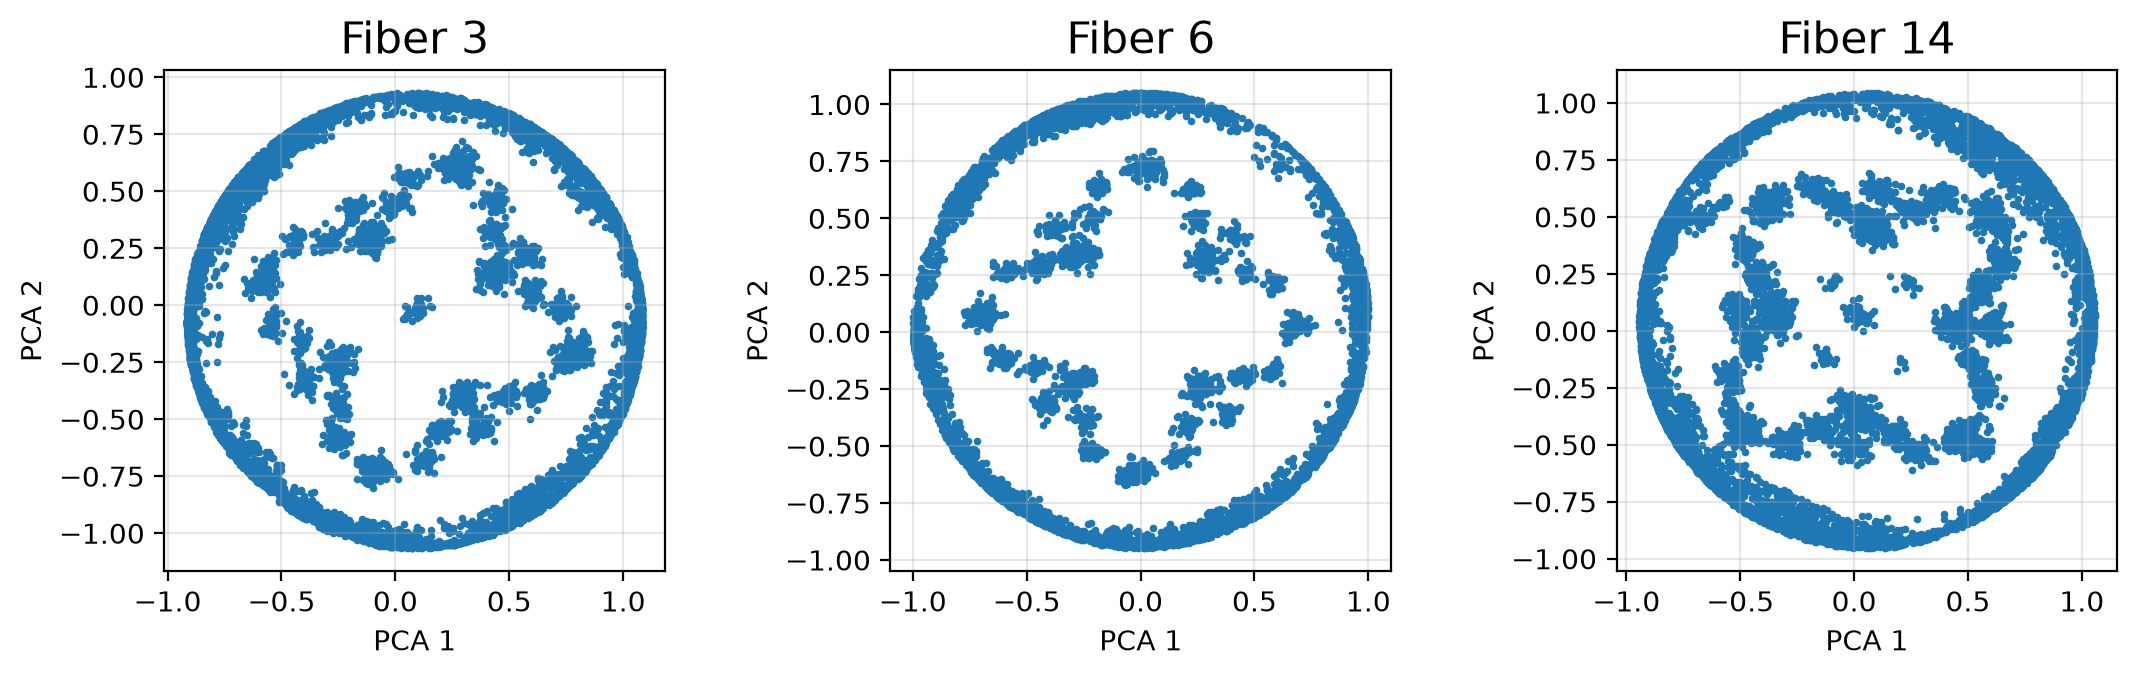

Saved local Rips figure to /Users/bradturow/Desktop/optical_flow_paper/results/paper/figures/Sample_Projections_rips.pdf


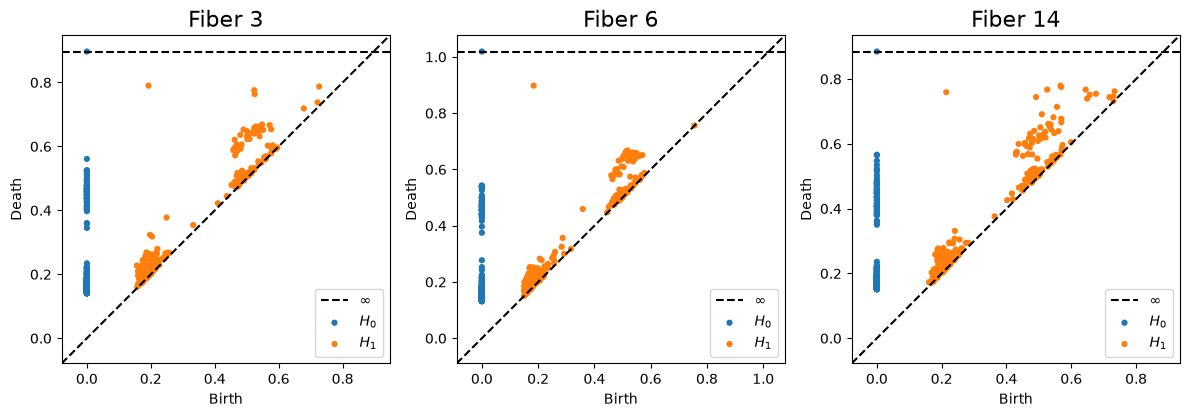

In [5]:
#Show local PCA and persistence of several fibers (Figure 17)
to_view = [3, 6, 14]
fiber_titles = [f"Fiber {j}" for j in to_view]

local_pca_path = figure_path("Sample_Projections.pdf")
fig, axes = cb.get_local_pca(
    data,
    cover.U,
    to_view=to_view,
    n_components=2,
    n_cols=3,
    titles=fiber_titles,
    point_size=3,
    save_path=str(local_pca_path),
    show=True,
)
output_paths["local_pca"] = local_pca_path

fiber_ids, dense_idx_list, local_rips = cb.get_local_rips(
    data,
    cover.U,
    to_view=to_view,
    maxdim=1,
    n_perm=local_rips_points,
    random_state=random_seed,
)
local_rips_path = figure_path("Sample_Projections_rips.pdf")
fig, axes = cb.plot_local_rips(
    fiber_ids,
    local_rips,
    n_cols=3,
    titles=fiber_titles,
    font_size=16,
    save_path=str(local_rips_path),
)
plt.show()
output_paths["local_persistence"] = local_rips_path


## Fiberwise Clustering

The local persistence diagrams show an interval around
$\alpha=0.3$ over which the number of connected components is stable. We
therefore run DBSCAN independently in each fiber with `eps=0.3`, join local
clusters that share samples, and form the global cluster graph $G$.


In [6]:
eps_values = dbscan_epsilon*np.ones(n_landmarks)
min_sample_values = dbscan_min_samples*np.ones(n_landmarks)

components, G, graph_dict, cl, summary = fiberwise_clustering(
    data,
    cover.U,
    eps_values,
    min_sample_values,
    build_pca_embeddings=True,
)

initial_ids = np.unique(components[components >= 0])
initial_point_counts = np.array(
    [np.sum(components == component) for component in initial_ids]
)

print(f"Total number of global clusters: {len(initial_ids)}")
print(f"Total number of unclustered points: {np.sum(components == -1)}")
print("Global components by size:")
print(np.argsort(initial_point_counts)[::-1])
print("Cardinality of each global component:")
print(initial_point_counts.tolist())


Total number of global clusters: 38
Total number of unclustered points: 18
Global components by size:
[ 0  2  1  8  7 22 10  5 15 11  4  3  9 23  6 14 21 17 16 12 18 20 19 13
 31 26 27 32 28 25 33 36 29 34 24 30 37 35]
Cardinality of each global component:
[111855, 3497, 3617, 1355, 1362, 1411, 1307, 3087, 3093, 1350, 1421, 1366, 1174, 1122, 1249, 1388, 1196, 1199, 1173, 1129, 1163, 1222, 1480, 1321, 10, 32, 93, 43, 34, 18, 9, 99, 35, 22, 14, 7, 21, 8]


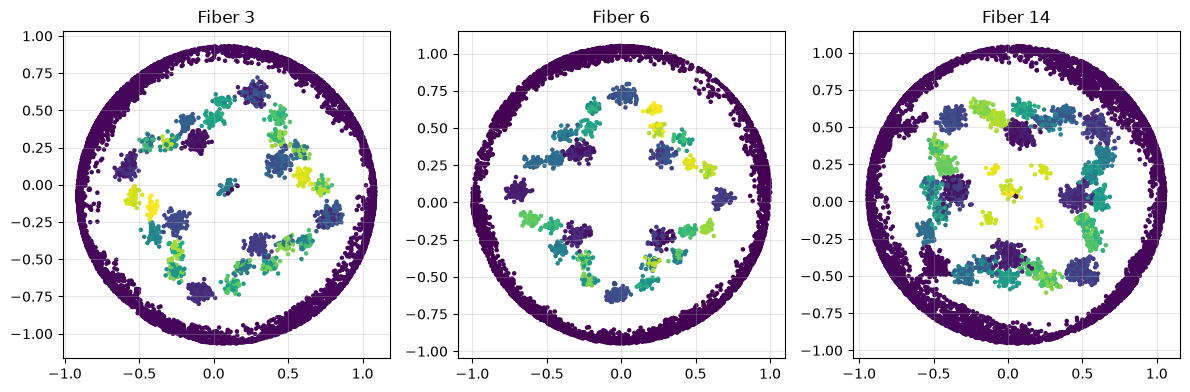

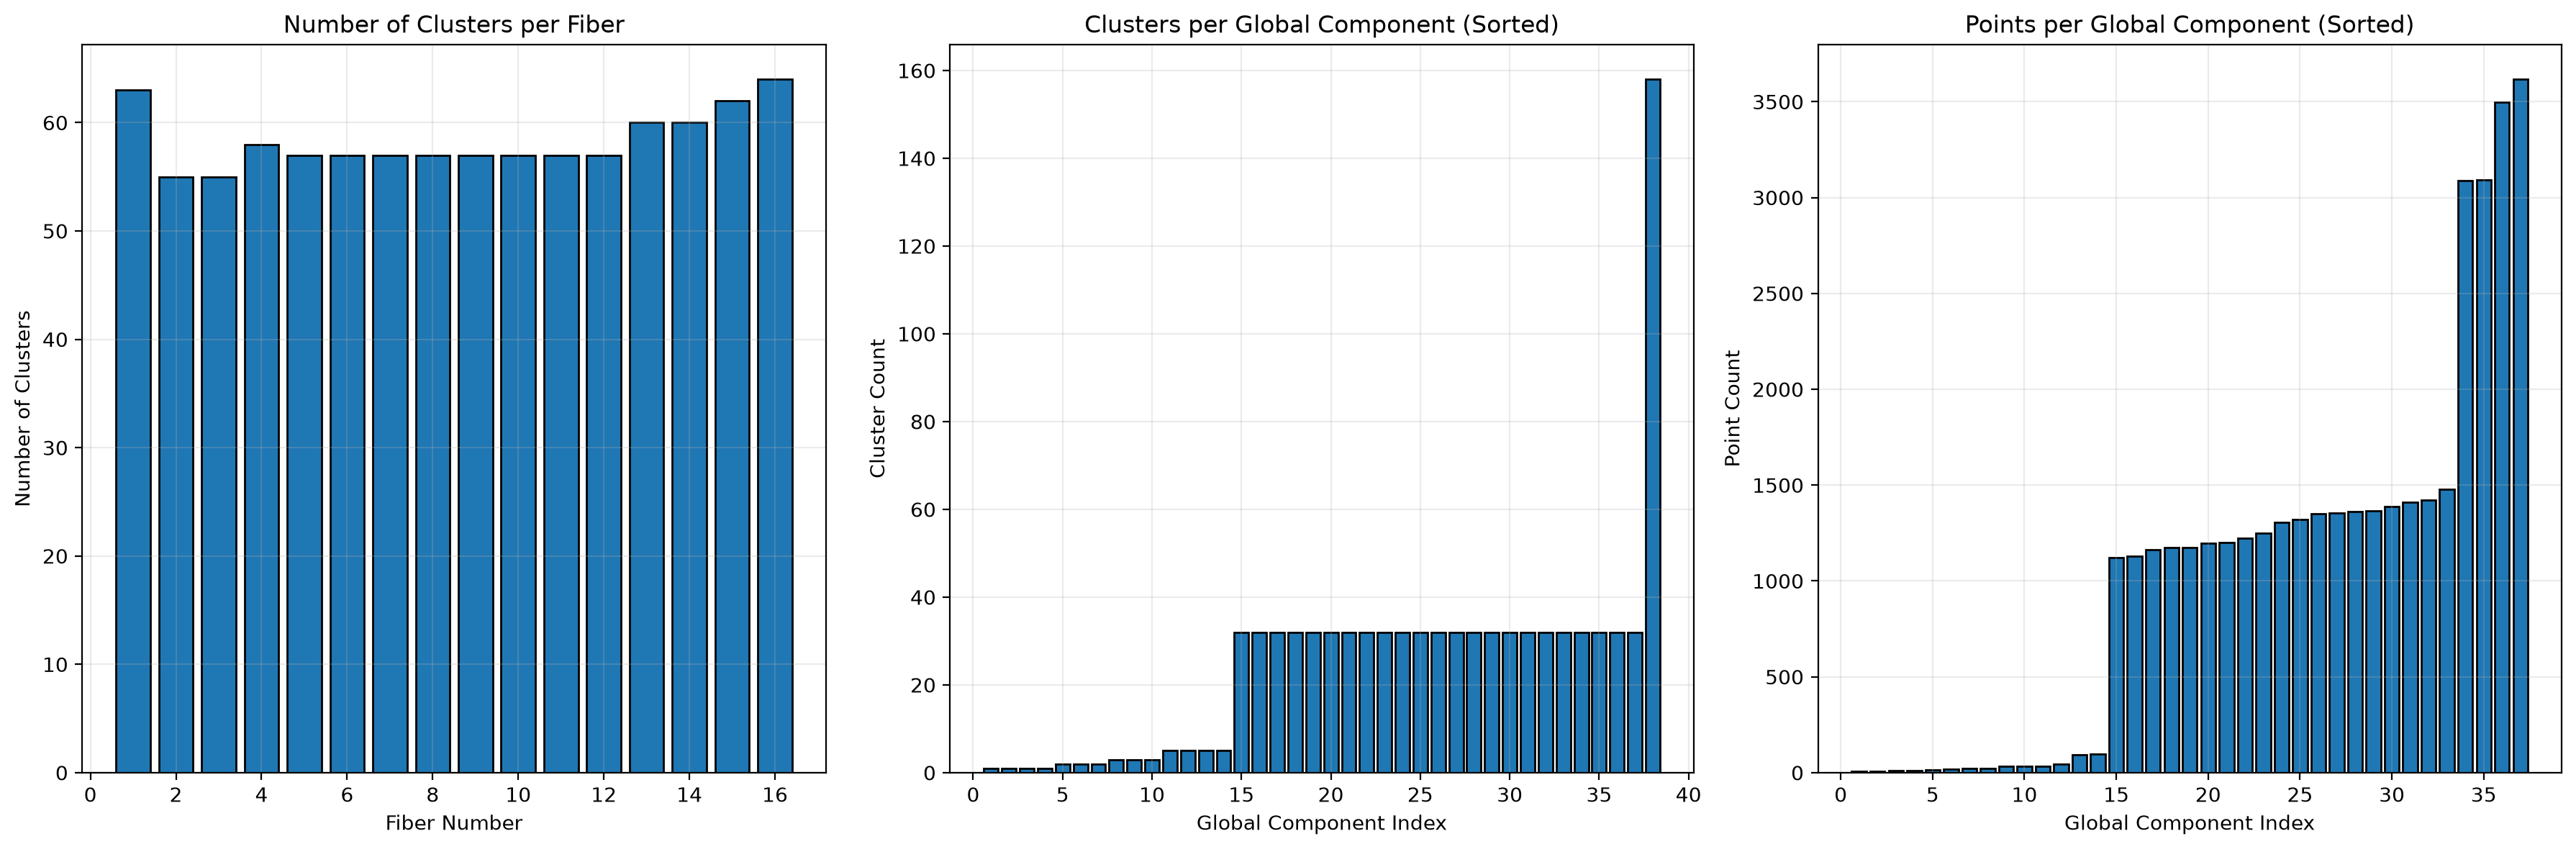

In [7]:
#Show clustered fibers and the initial clustering summary (Figures 18 and 19)
clustered_fibers_path = figure_path("Sample_Clustered_Fibers.pdf")
fig, axes = plot_fiberwise_pca_grid(
    summary,
    to_view=[3, 6, 14],
    n_cols=3,
    save_path=str(clustered_fibers_path),
)
output_paths["clustered_fibers"] = clustered_fibers_path

clustering_summary_path = figure_path("Sample_Clustered_Fibers_summary.pdf")
fig, axes = plot_fiberwise_summary_bars(
    summary,
    hide_biggest=True,
    save_path=None,
)
for bar in axes[1].patches:
    bar.set_facecolor("#55A868")
for bar in axes[2].patches:
    bar.set_facecolor("indianred")
fig.savefig(clustering_summary_path, bbox_inches="tight")
plt.show()
output_paths["initial_clustering_summary"] = clustering_summary_path


## Binary Step-Edge Patches

The local filament clusters correspond to binary step-edge range patches with
camera motion applied along the predominant flow axis. The publication-scale workflow
recreates the three panels in Figure 20 using the ten pattern indices recorded
in the legacy source.


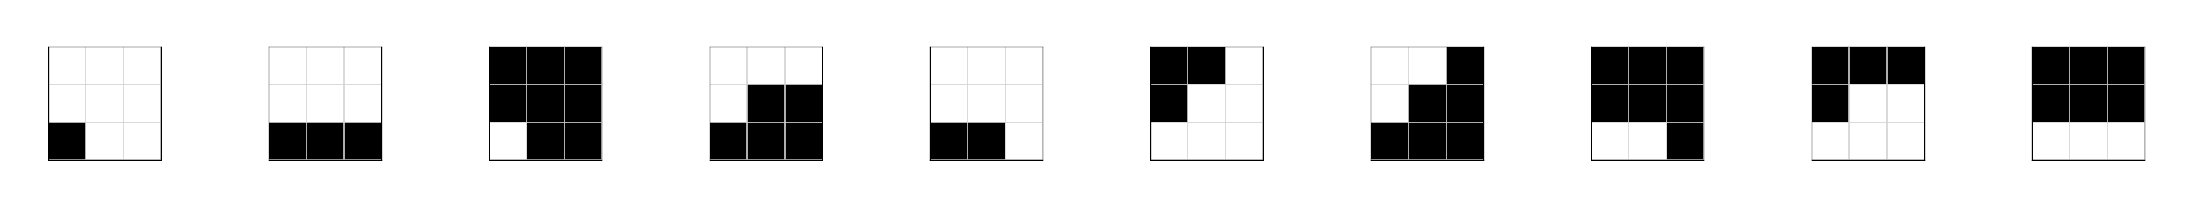

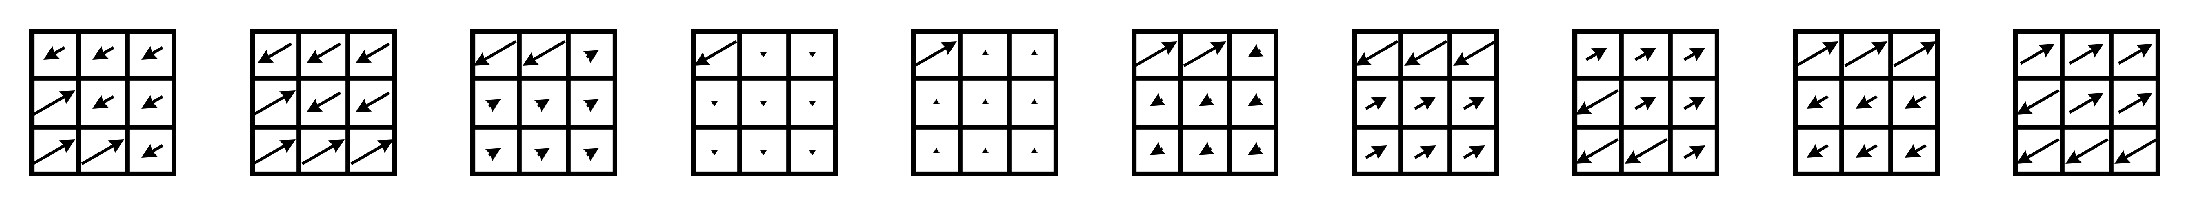

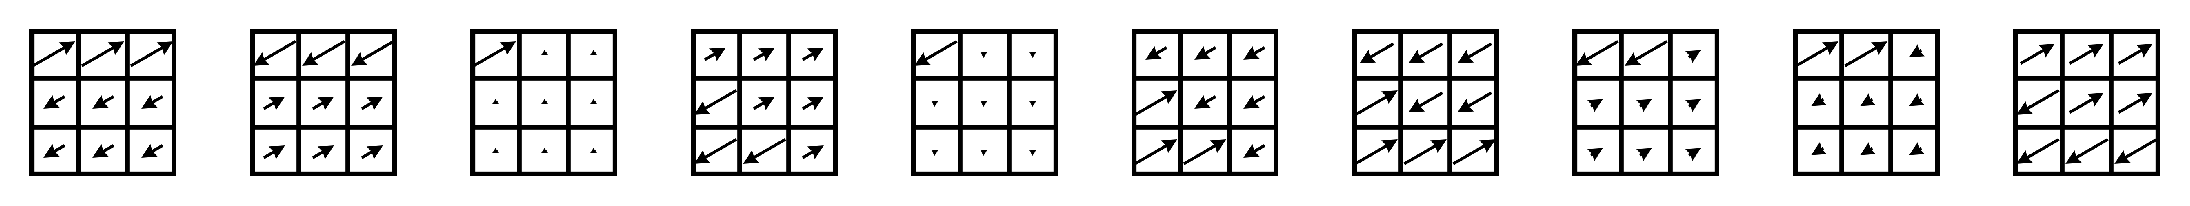

In [8]:
def range_patch_vis(patch):
    fig, ax = plt.subplots(figsize=(2, 2), dpi=120)
    image = np.asarray(patch).reshape(3, 3, order="F")
    ax.imshow(np.flipud(image), cmap="gray", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(-0.5, 3, 1))
    ax.set_yticks(np.arange(-0.5, 3, 1))
    ax.grid(color="lightgray", linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(length=0)
    return fig


angle = np.pi/6
range_data = cb.make_all_step_edges()
flow_data = cb.make_all_step_edges(angle=angle)
range_order = [28, 32, 44, 24, 13, 0, 4, 16, 52, 41]
flow_order_a = range_order
flow_order_b = [0, 4, 16, 52, 41, 28, 32, 44, 24, 13]

binary_range_path = figure_path("Binary_Range_Patch_Sample.pdf")
fig, axes = cb.show_data_vis(
    range_data[range_order],
    range_patch_vis,
    sampling_method=None,
    max_samples=10,
    n_cols=10,
    figsize_per_cell=1.5,
    save_path=str(binary_range_path),
)
plt.show()

binary_flow_a_path = figure_path("Binary_Flow_Patch_SampleA.pdf")
fig, axes = cb.show_data_vis(
    flow_data[flow_order_a],
    patch_vis,
    sampling_method=None,
    max_samples=10,
    n_cols=10,
    figsize_per_cell=1.5,
    save_path=str(binary_flow_a_path),
)
plt.show()

binary_flow_b_path = figure_path("Binary_Flow_Patch_SampleB.pdf")
fig, axes = cb.show_data_vis(
    flow_data[flow_order_b],
    patch_vis,
    sampling_method=None,
    max_samples=10,
    n_cols=10,
    figsize_per_cell=1.5,
    save_path=str(binary_flow_b_path),
)
plt.show()

output_paths.update({
    "binary_range_patches": binary_range_path,
    "binary_flow_patches_a": binary_flow_a_path,
    "binary_flow_patches_b": binary_flow_b_path,
})


# Global Clusters

Test each initial global component for a prominent one-dimensional class. As
in the recovered analysis, we call a component circular when the longest
interval satisfies $d>2b$.


In [9]:
C = np.zeros((len(initial_ids) + 1, len(data)), dtype=bool)
for row, component in enumerate(initial_ids):
    C[row] = components == component
C[-1] = components == -1


def classify_circular_components(rips_results):
    circular = []
    other = []
    records = []
    for component, result in enumerate(rips_results):
        diagram = (
            np.empty((0, 2))
            if result is None
            else np.asarray(result["dgms"][1])
        )
        if len(diagram) == 0:
            record = {"birth": 0.0, "death": 0.0, "lifetime": 0.0}
            other.append(component)
        else:
            birth, death = diagram[np.argmax(diagram[:, 1] - diagram[:, 0])]
            record = {
                "birth": float(birth),
                "death": float(death),
                "lifetime": float(death - birth),
            }
            if death > 2*birth:
                circular.append(component)
            else:
                other.append(component)
        records.append(record)
    return circular, other, records


fiber_ids, dense_idx_list, initial_component_rips = cb.get_local_rips(
    data,
    C,
    maxdim=1,
    n_perm=component_rips_points,
    random_state=random_seed,
)
initial_circular_components, initial_other_components, initial_h1_records = (
    classify_circular_components(initial_component_rips)
)

print("Components with circular features:")
print(initial_circular_components)
print(
    f"Number of circular components: {len(initial_circular_components)}, "
    f"number of other components: {len(initial_other_components)}"
)


Components with circular features:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of circular components: 24, number of other components: 15


/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The inp

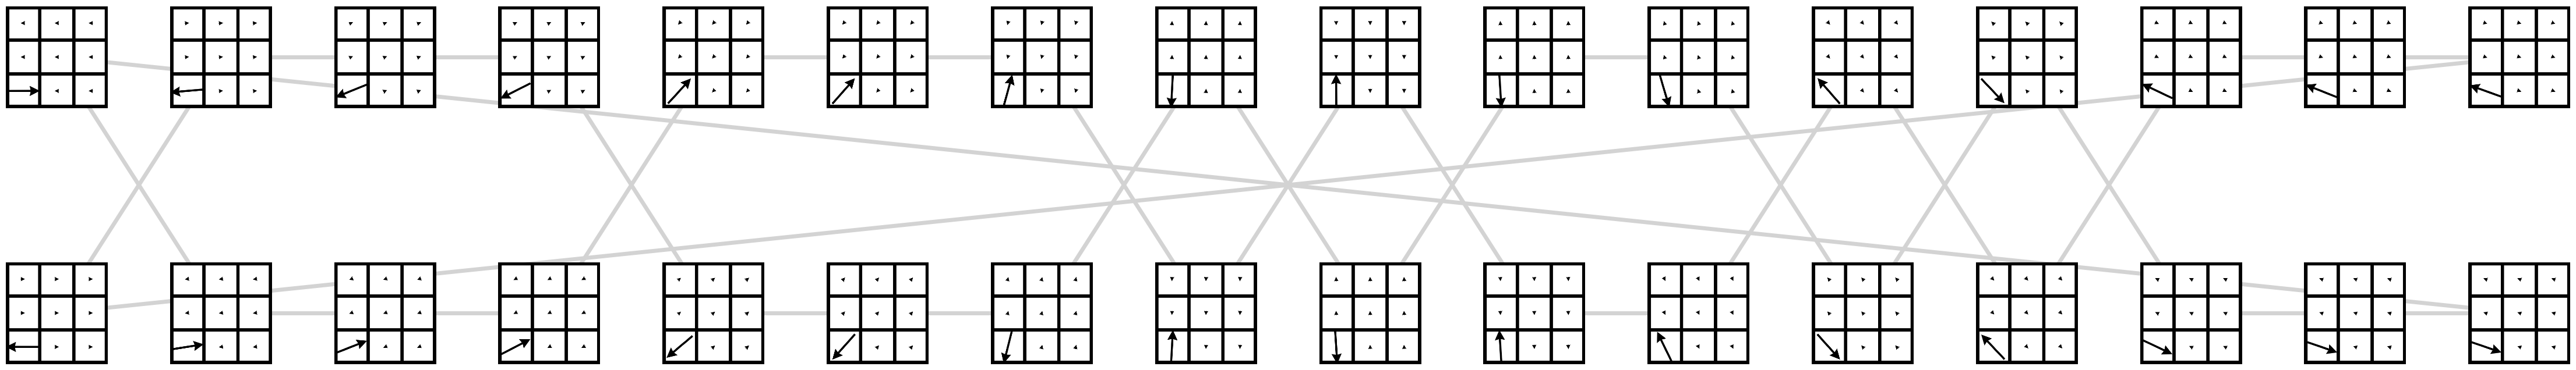

In [10]:
#Visualize one of the double-cover components of G (Figure 21)
graph_components = list(nx.connected_components(G))
Gm = G.subgraph(graph_components[1]).copy()

indices = []
clusters = np.zeros((len(Gm.nodes()), 2), dtype=int)
for cluster_num, (fiber, label) in enumerate(Gm.nodes()):
    matches = np.where(cl[fiber] == label)[0]
    if len(matches) == 0:
        raise RuntimeError(f"No representative for cluster {(fiber, label)}")
    indices.append(matches.min())
    clusters[cluster_num] = np.array([fiber, label])

patch_reps = data[np.asarray(indices)]
component_graph_path = figure_path("G_component_vis.pdf")
fig, ax = make_patch_cluster_diagram(
    patch_reps,
    clusters,
    Gm,
    patch_vis,
    image_zoom=0.35,
    row_spacing=4,
    col_spacing=3.5,
    line_color="lightgray",
    line_width=5,
    save_path=str(component_graph_path),
)
plt.show()
output_paths["double_cover_component"] = component_graph_path


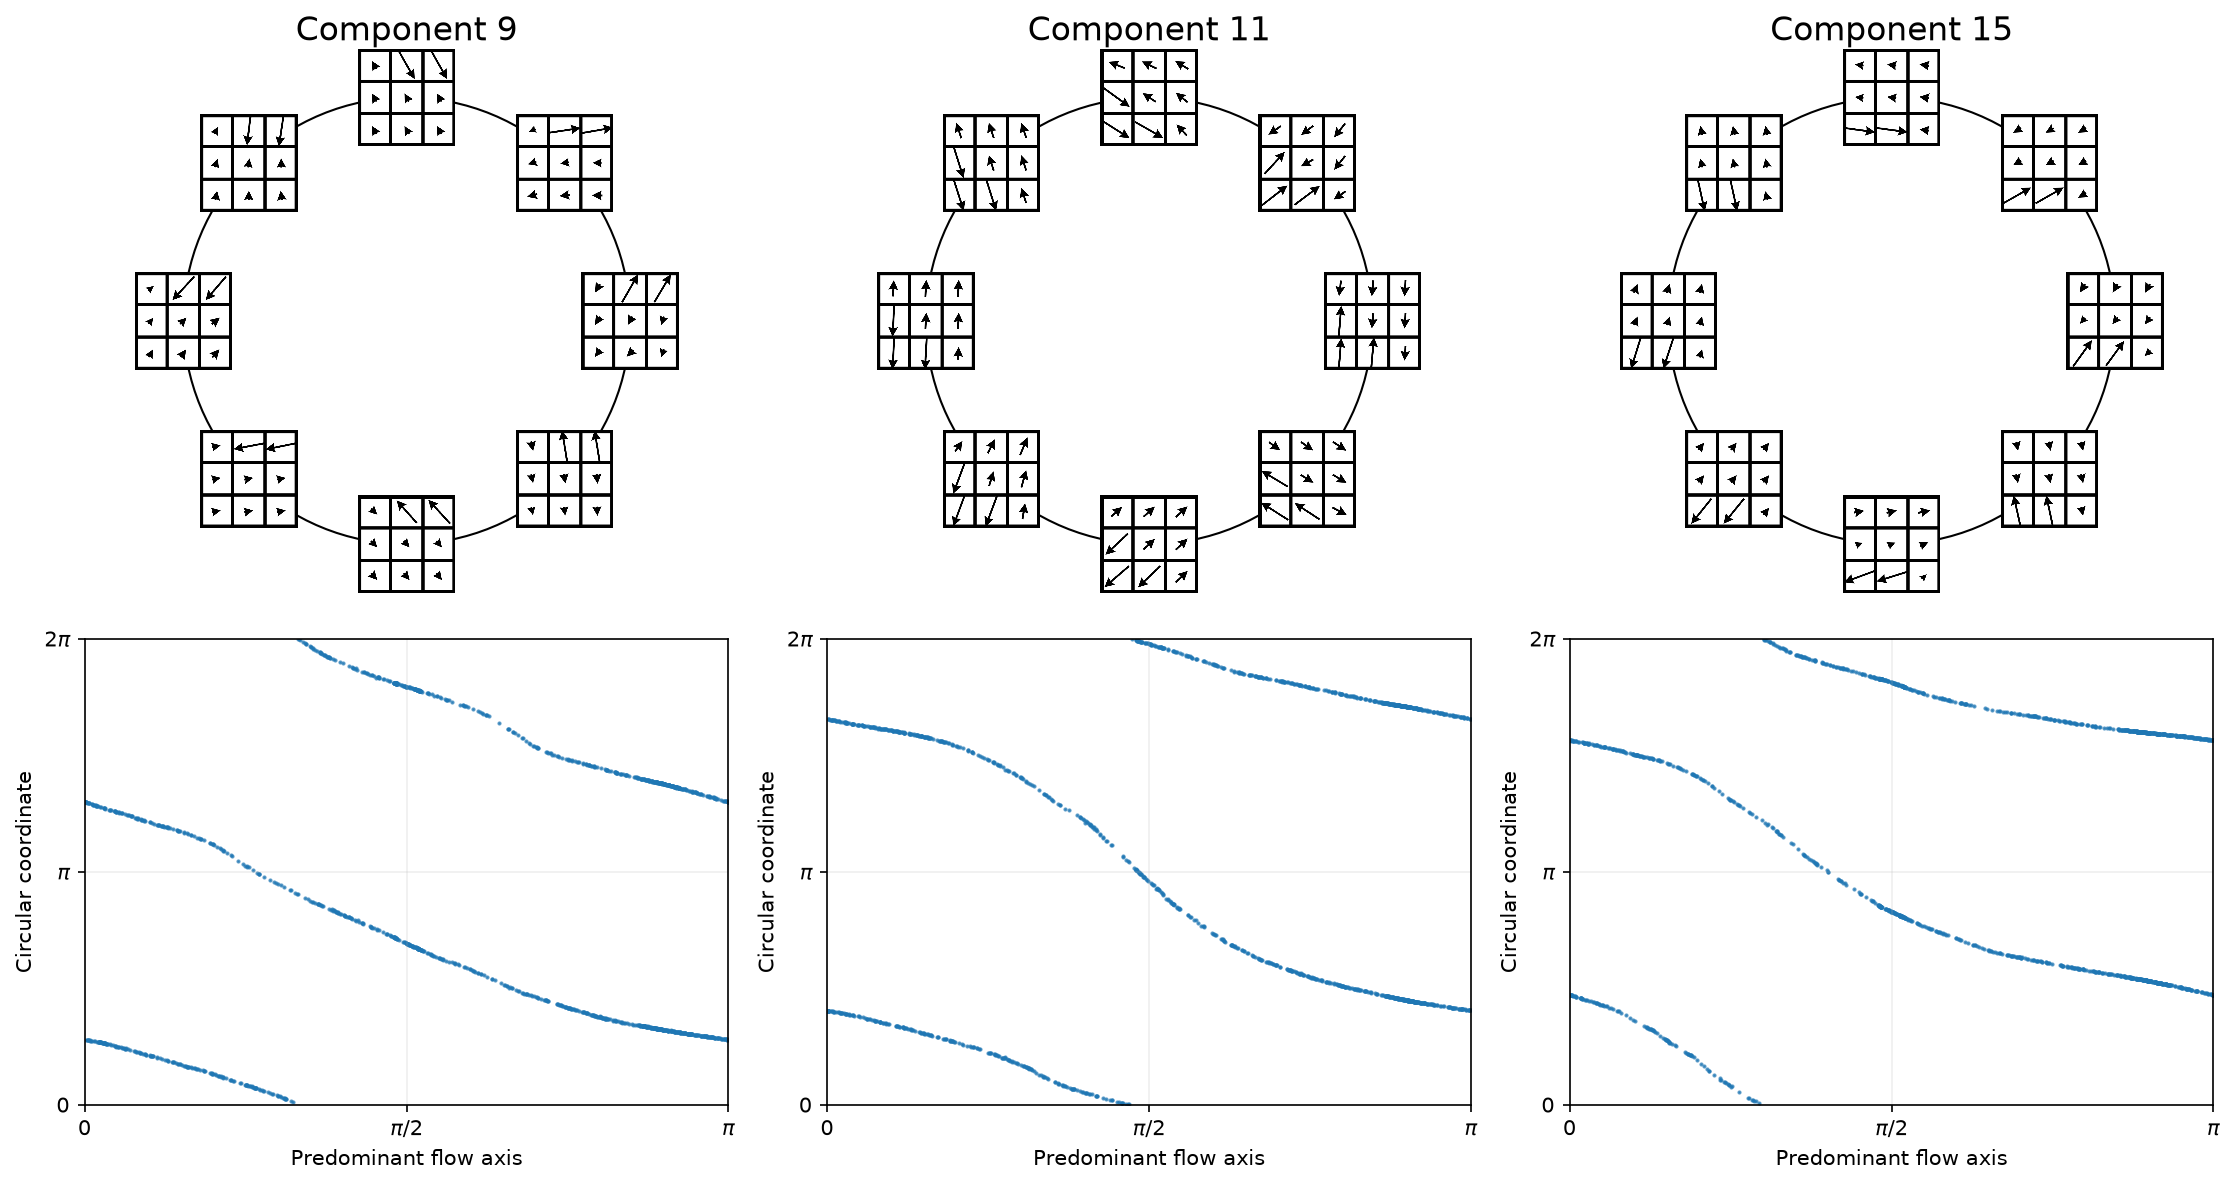

In [11]:
#Compute and display circular coordinates for three components (Figure 22)
selected_components = [9, 11, 15]
selected_datasets = []
selected_angles = []

for component in selected_components:
    if component not in initial_circular_components:
        raise RuntimeError(f"Component {component} is no longer circular")
    indices = components == component
    component_data = data[indices]
    cc = CircularCoords(component_data, 100, prime=17)
    selected_datasets.append(component_data)
    selected_angles.append(cc.get_coordinates())

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
    dpi=150,
    gridspec_kw={"height_ratios": [1.15, 1]},
)
for column, (component, dataset, angles) in enumerate(
    zip(selected_components, selected_datasets, selected_angles)
):
    circle_vis(
        dataset,
        angles,
        patch_vis,
        per_circle=8,
        radius=1,
        extent_factor=1.2,
        zoom=0.13,
        ax=axes[0, column],
    )
    axes[0, column].set_title(f"Component {component}", fontsize=16)

    indices = components == component
    axes[1, column].scatter(
        predom_dirs[indices],
        angles,
        s=1,
        alpha=0.7,
    )
    axes[1, column].set_xlim(0, np.pi)
    axes[1, column].set_ylim(0, 2*np.pi)
    axes[1, column].set_xticks(
        [0, np.pi/2, np.pi],
        [r"$0$", r"$\pi/2$", r"$\pi$"],
    )
    axes[1, column].set_yticks(
        [0, np.pi, 2*np.pi],
        [r"$0$", r"$\pi$", r"$2\pi$"],
    )
    axes[1, column].set_xlabel("Predominant flow axis")
    axes[1, column].set_ylabel("Circular coordinate")
    axes[1, column].grid(alpha=0.2)

sample_cc_path = figure_path("Sample_ccs_w_Corrs.pdf")
fig.tight_layout()
fig.savefig(sample_cc_path, bbox_inches="tight")
plt.show()
output_paths["sample_circular_coordinates"] = sample_cc_path


## Cluster Persistence

The recovered code assigns each graph edge the intersection cardinality divided
by the average cardinality of its endpoint clusters (`rel_card2`). This is the
convention used to reproduce the saved figures. The manuscript currently writes
a maximum in the denominator; that formula should be reconciled before the paper
is finalized.


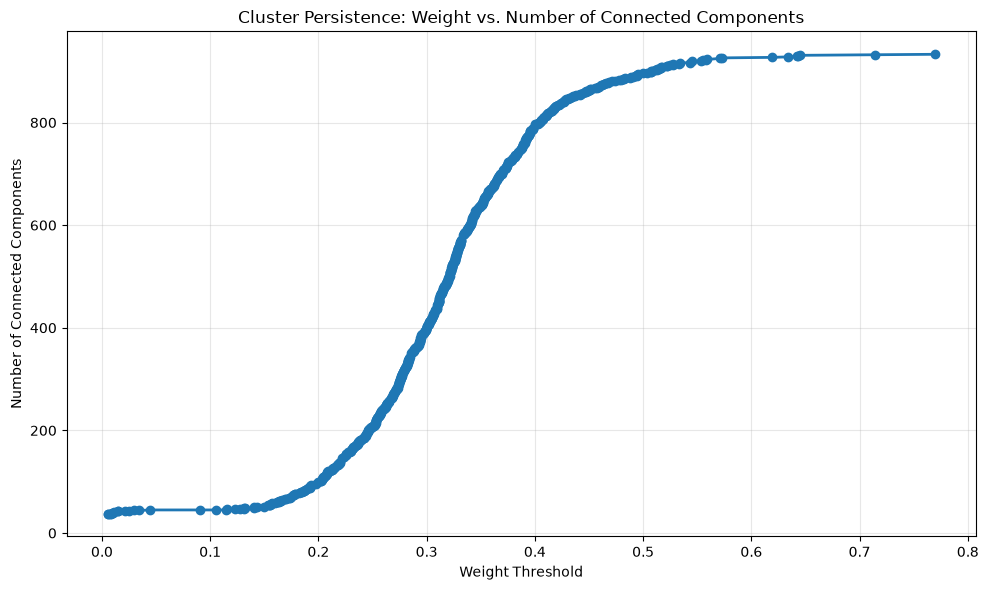

In [12]:
G = get_weights(G, method="rel_card2")
cluster_persistence_path = figure_path("Cluster_Persistence.pdf")
cluster_persistence = get_cluster_persistence(
    G,
    save_path=str(cluster_persistence_path),
)
output_paths["cluster_persistence"] = cluster_persistence_path


In [13]:
#Replace G with G^(0.07)
(
    filtered_components,
    filtered_G,
    filtered_graph_dict,
    filtered_cl,
    comp_inds,
) = get_filtered_cluster_graph(
    data,
    G,
    cl,
    thresh=graph_weight_threshold,
    rule="to_smaller_cluster",
    show_results=False,
)

print(
    f"Threshold: {graph_weight_threshold}, "
    f"global clusters: {len(comp_inds)}"
)
print(f"Number of deleted edges: {len(G.edges) - len(filtered_G.edges)}")


Threshold: 0.07, global clusters: 45
Number of deleted edges: 14


## The Filtered Cluster Graph

Plot the filtered component counts and show how the weak edges split the old
primary component $G_0$ into the extended optical flow torus and several
secondary components.


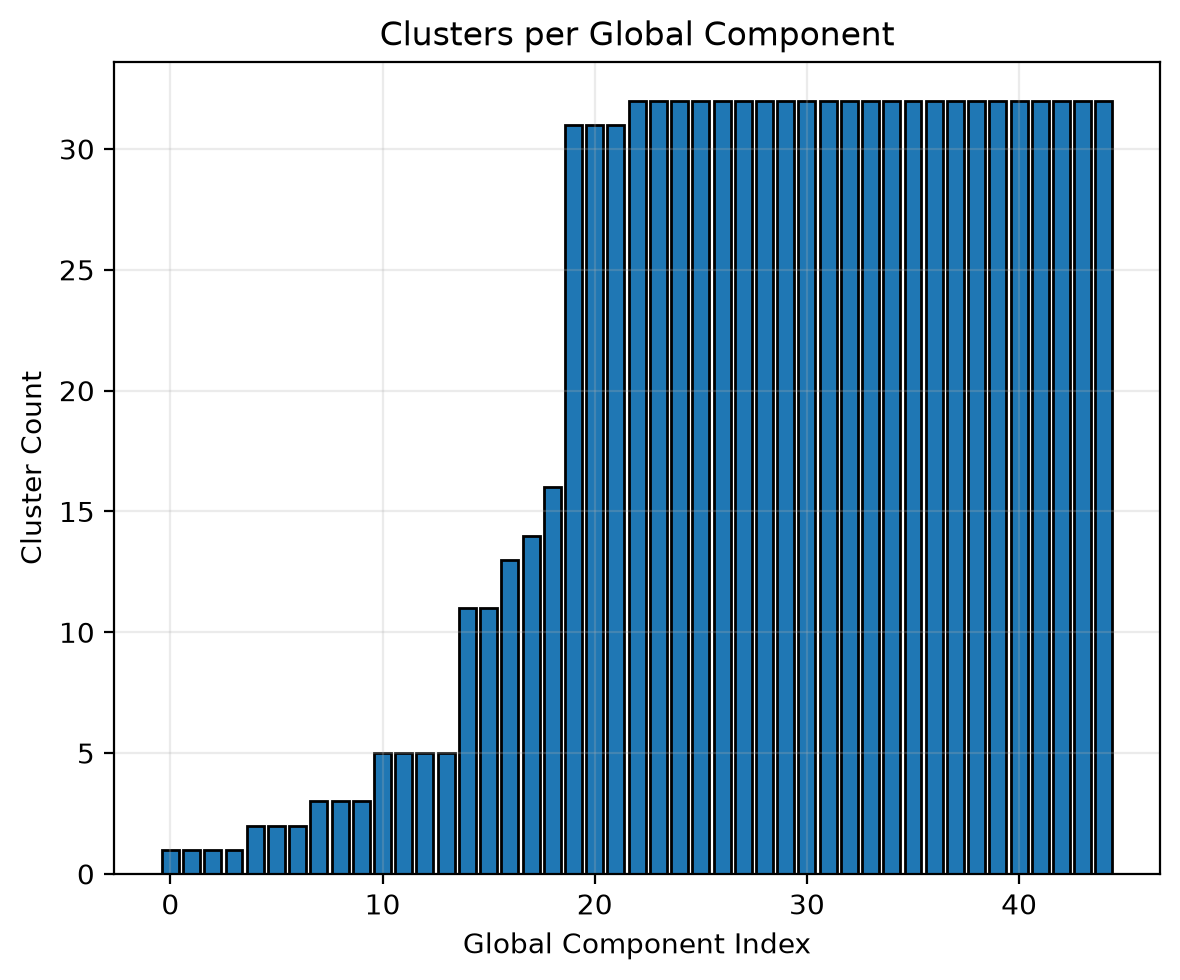

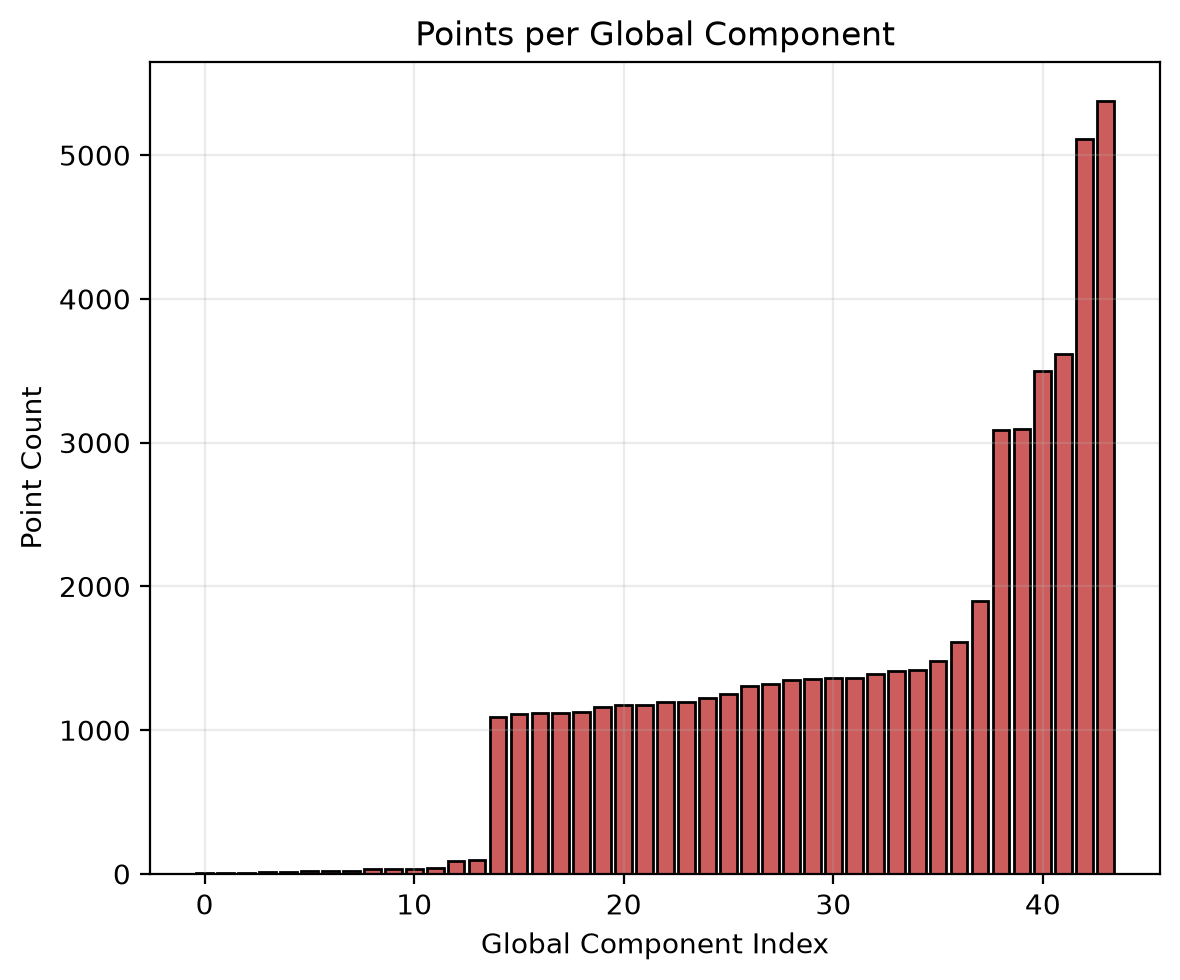

In [14]:
#Summary of G^(0.07) (Figure 24a)
filtered_graph_components = list(nx.connected_components(filtered_G))
filtered_cluster_counts = sorted(
    [len(component) for component in filtered_graph_components]
)
filtered_point_counts = sorted(comp_inds.sum(axis=1).astype(int).tolist())[:-1]

#The historical filenames are reversed: Point_Count contains cluster counts.
point_count_path = figure_path("Point_Count.pdf")
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
ax.bar(
    np.arange(len(filtered_cluster_counts)),
    filtered_cluster_counts,
    edgecolor="black",
)
ax.set(
    title="Clusters per Global Component",
    xlabel="Global Component Index",
    ylabel="Cluster Count",
)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(point_count_path, bbox_inches="tight")
plt.show()

cluster_count_path = figure_path("Cluster_Count.pdf")
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
ax.bar(
    np.arange(len(filtered_point_counts)),
    filtered_point_counts,
    color="indianred",
    edgecolor="black",
)
ax.set(
    title="Points per Global Component",
    xlabel="Global Component Index",
    ylabel="Point Count",
)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(cluster_count_path, bbox_inches="tight")
plt.show()

output_paths.update({
    "filtered_cluster_counts": point_count_path,
    "filtered_point_counts": cluster_count_path,
})


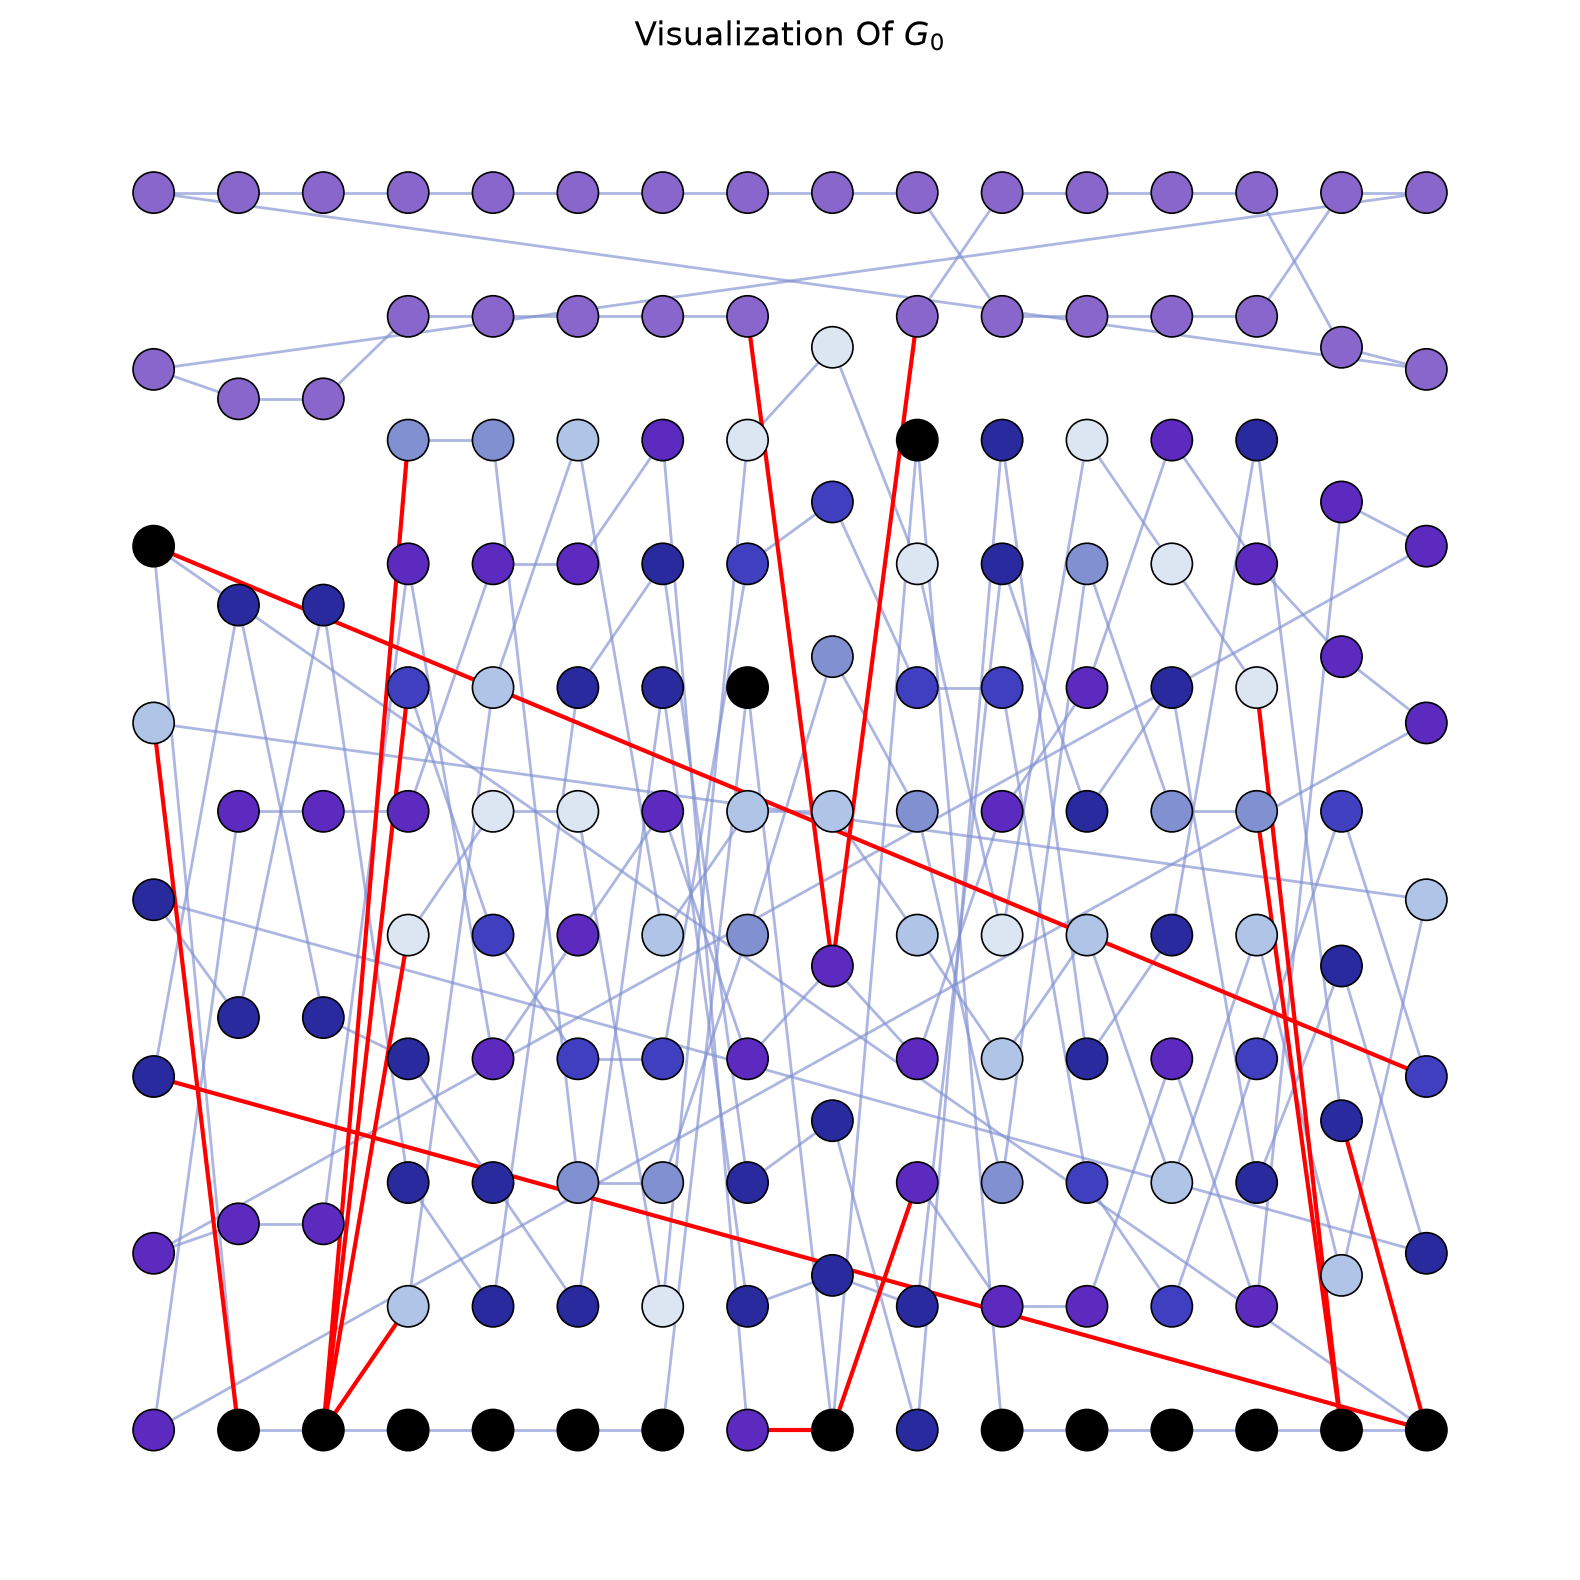

In [15]:
#View G0 before and after filtering (Figure 24b)
initial_graph_components = list(nx.connected_components(G))
G0_nodes = max(initial_graph_components, key=len)
G0 = G.subgraph(G0_nodes).copy()
filtered_G0 = filtered_G.subgraph(G0_nodes).copy()

subcomponents = list(nx.connected_components(filtered_G0))
subcomponent_point_counts = []
for subcomponent in subcomponents:
    indices = set()
    for node in subcomponent:
        indices.update(filtered_G0.nodes[node].get("indices", []))
    subcomponent_point_counts.append(len(indices))
torus_subcomponent = int(np.argmax(subcomponent_point_counts))

palette = [
    "#8090D1",
    "#3F3FBF",
    "#8866CC",
    "#5C2ABF",
    "#DCE6F2",
    "#B0C4E8",
    "#2A2A9F",
]
node_to_subcomponent = {
    node: component
    for component, nodes in enumerate(subcomponents)
    for node in nodes
}
node_colors = [
    "black"
    if node_to_subcomponent[node] == torus_subcomponent
    else palette[node_to_subcomponent[node] % len(palette)]
    for node in G0.nodes()
]

coordinates = get_G_vertex_coords(G0)
coordinates[:, 1] *= 1.15
positions = {
    node: coordinates[index]
    for index, node in enumerate(G0.nodes())
}
retained_edges = [edge for edge in G0.edges() if filtered_G0.has_edge(*edge)]
removed_edges = [edge for edge in G0.edges() if not filtered_G0.has_edge(*edge)]

fig, ax = plt.subplots(figsize=(8, 8), dpi=200)
nx.draw_networkx_edges(
    G0,
    positions,
    edgelist=retained_edges,
    edge_color="#8090D1",
    width=1,
    alpha=0.65,
    ax=ax,
)
nx.draw_networkx_edges(
    G0,
    positions,
    edgelist=removed_edges,
    edge_color="red",
    width=1.5,
    ax=ax,
)
nx.draw_networkx_nodes(
    G0,
    positions,
    node_color=node_colors,
    edgecolors="black",
    node_size=220,
    linewidths=0.6,
    ax=ax,
)
ax.set_title(r"Visualization Of $G_0$")
ax.axis("off")
graph_summary_path = figure_path(
    "Optical_Flow_Paper_DiagramsLargest_Cluster_Graph_Vis2.pdf"
)
fig.tight_layout()
fig.savefig(graph_summary_path, bbox_inches="tight")
plt.show()
output_paths["filtered_primary_graph"] = graph_summary_path


In [16]:
#Check which filtered components have a significant 1D persistent class
fiber_ids, dense_idx_list, filtered_component_rips = cb.get_local_rips(
    data,
    comp_inds,
    maxdim=1,
    n_perm=component_rips_points,
    random_state=random_seed,
)
circular_components, other_components, filtered_h1_records = (
    classify_circular_components(filtered_component_rips)
)

print("Components with circular features:")
print(circular_components)
print(
    f"Number of circular components: {len(circular_components)}, "
    f"number of other components: {len(other_components)}"
)


/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Components with circular features:
[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Number of circular components: 27, number of other components: 18


/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/bradturow/Desktop/optical_flow_paper/.venv/lib/python3.13/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


## Composite Circles

Four non-circular components account for almost all of the remaining data. In
the paper run they have cardinalities `(1897, 1088)` and `(1612, 1120)` and
pair off to form the two missing step-edge circles. Cardinalities are used here
instead of execution-order-dependent component numbers.


Saved local Rips figure to /Users/bradturow/Desktop/optical_flow_paper/results/paper/figures/composite_circles_ripser.pdf


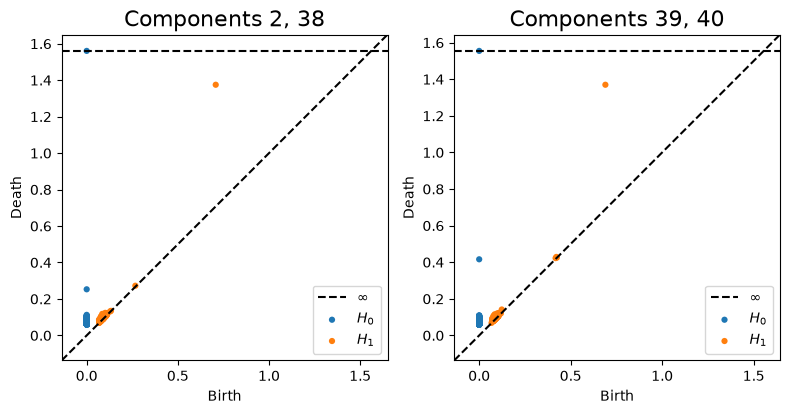

In [17]:
component_sizes = comp_inds.sum(axis=1).astype(int)


def component_with_size(size, excluded=()):
    matches = [
        component
        for component in other_components
        if component not in excluded and component_sizes[component] == size
    ]
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one non-circular component of size {size}; found {matches}"
        )
    return matches[0]


pair_a = (
    component_with_size(1897),
    component_with_size(1088),
)
pair_b = (
    component_with_size(1612),
    component_with_size(1120),
)
bunches = [pair_a, pair_b]
bunch_inds = np.asarray(
    [comp_inds[a] | comp_inds[b] for a, b in bunches],
    dtype=bool,
)
bunch_titles = [
    f"Components {a}, {b}"
    for a, b in bunches
]

#Show persistence of the two component pairs (Figure 25a)
fiber_ids, dense_idx_list, composite_rips = cb.get_local_rips(
    data,
    bunch_inds,
    maxdim=1,
    n_perm=component_rips_points,
    random_state=random_seed,
)
composite_rips_path = figure_path("composite_circles_ripser.pdf")
fig, axes = cb.plot_local_rips(
    fiber_ids,
    composite_rips,
    n_cols=2,
    titles=bunch_titles,
    font_size=16,
    save_path=str(composite_rips_path),
)
plt.show()
output_paths["composite_circle_persistence"] = composite_rips_path


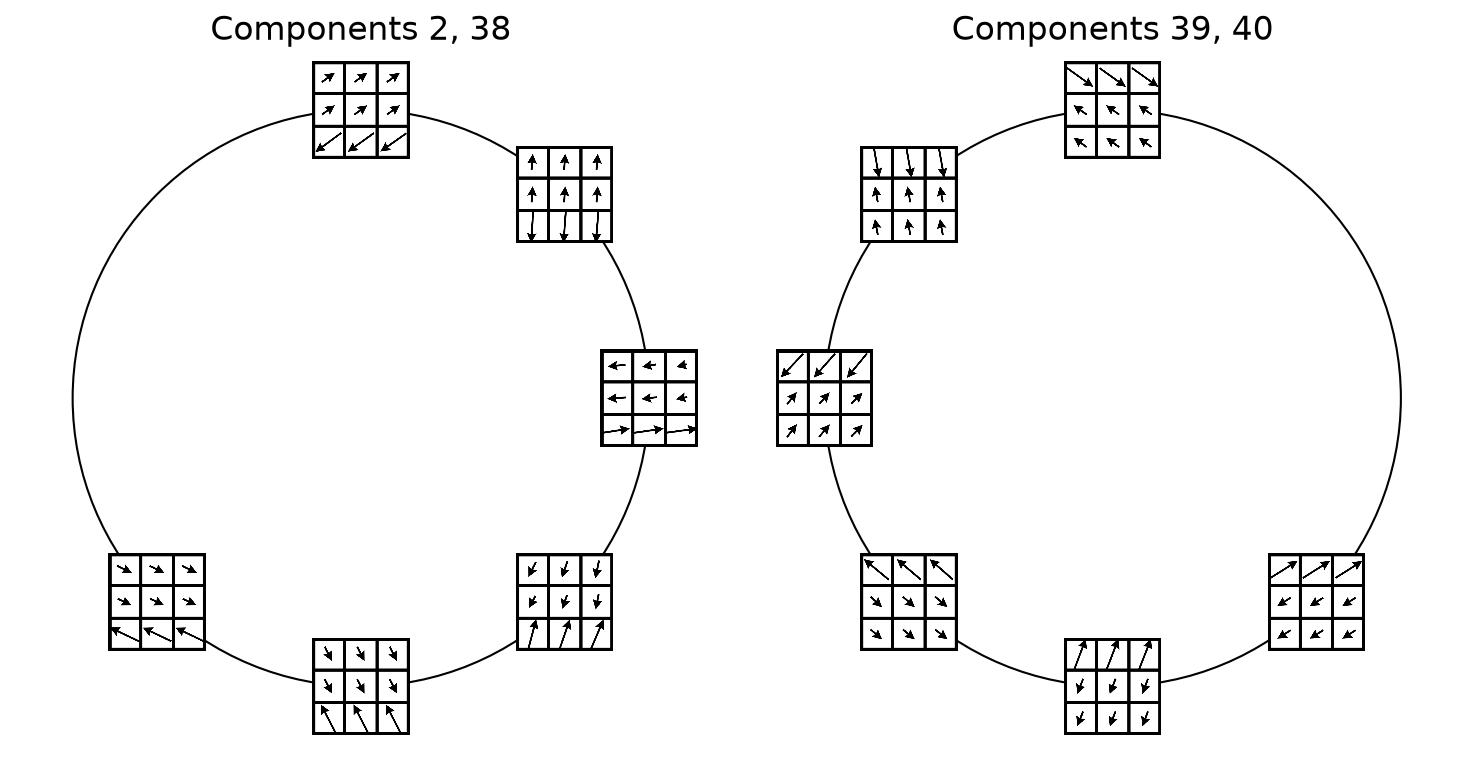

In [18]:
#Add deterministic bridge samples and compute circular coordinates (Figure 25b)
patch_types = cb.get_patch_types_list()
synthetic_rng = np.random.default_rng(random_seed)
bridge_patterns = [18, 16]
bridge_samples = []
composite_datasets = []
composite_angles = []

for pair_number, pattern in enumerate(bridge_patterns):
    synthetic, synthetic_angles = cb.make_step_edges(
        samples_per_filament,
        patch_types[pattern],
        rng=synthetic_rng,
    )
    bridge_samples.append(synthetic)
    empirical = data[bunch_inds[pair_number]]
    boosted = np.concatenate((empirical, synthetic))
    cc = CircularCoords(boosted, 100, prime=17)
    composite_datasets.append(empirical)
    composite_angles.append(
        cc.get_coordinates()[:-samples_per_filament]
    )

missing_circles_path = figure_path("Missing_Circles_cc.pdf")
fig, axes = circle_vis_grid(
    composite_datasets,
    composite_angles,
    patch_vis,
    titles=bunch_titles,
    per_circle=8,
    circle_zoom=0.13,
    n_cols=2,
    figsize_per_panel=5,
    save_path=str(missing_circles_path),
)
plt.show()
output_paths["missing_circle_coordinates"] = missing_circles_path


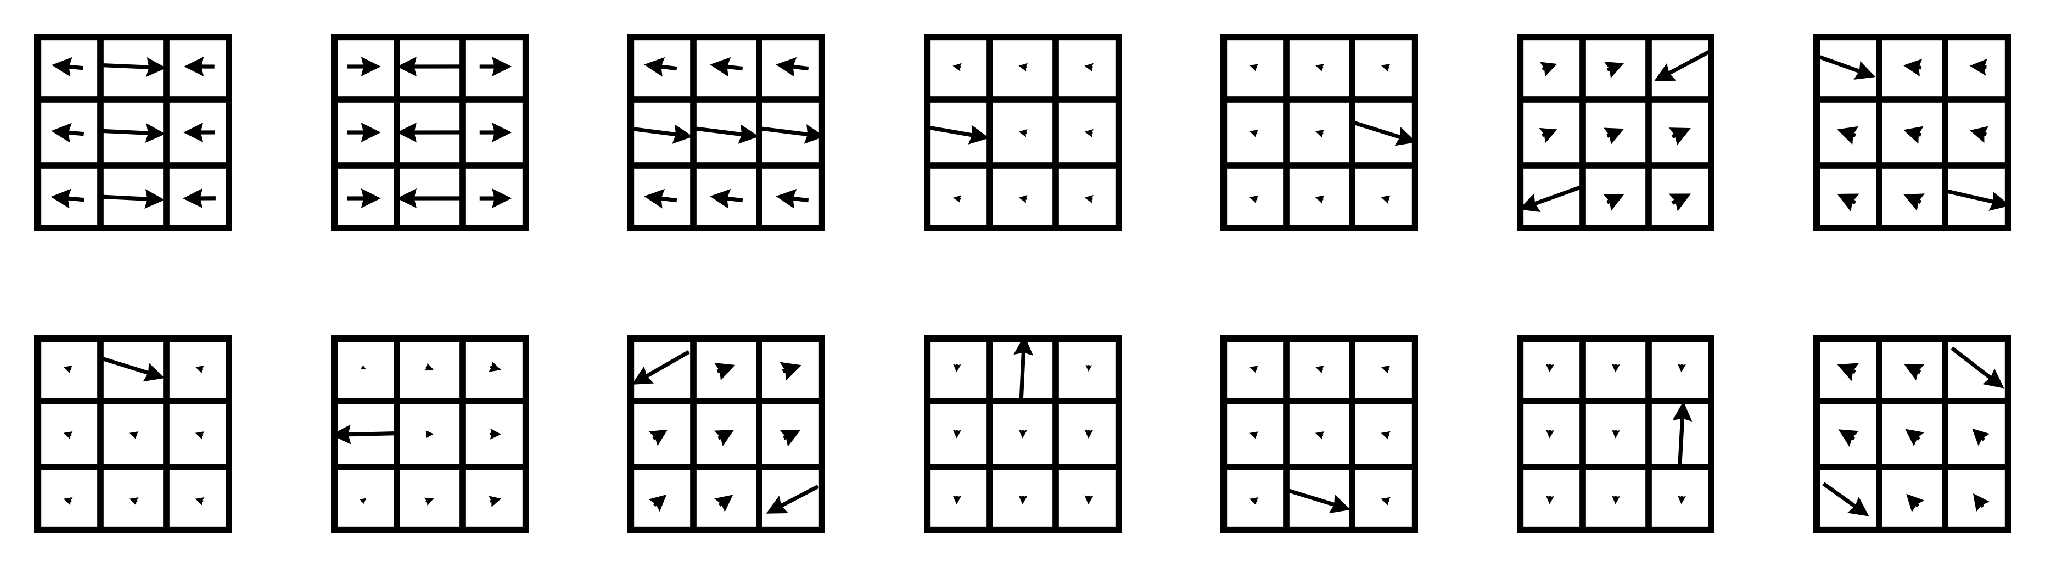

In [19]:
#Show representative outlier and quadratic-gradient patches (Figure 26)
paired_components = {component for pair in bunches for component in pair}
noise_components = [
    component
    for component in other_components
    if component not in paired_components
]
noise_datasets = [data[comp_inds[component]] for component in noise_components]
noise_samples = np.vstack([dataset[0] for dataset in noise_datasets])

quadratic_patches_path = figure_path("Quadratic_Patches.pdf")
fig, axes = cb.show_data_vis(
    noise_samples,
    patch_vis,
    sampling_method=None,
    max_samples=len(noise_samples),
    n_cols=7,
    save_path=str(quadratic_patches_path),
)
plt.show()
output_paths["outlier_patches"] = quadratic_patches_path


## Portable Boundary-Circle Artifact

Finally, assemble the 26 complete circles and the two paired-off circles. The
same deterministic synthetic bridge samples used above fill the two incomplete
circles. The result is saved without pickle for use by Notebook 03.


In [20]:
circular_set = set(circular_components)
torus_component = max(
    circular_set,
    key=lambda component: int(comp_inds[component].sum()),
)
single_circle_components = circular_set - {torus_component}
ordered_single_components = sorted(
    single_circle_components,
    key=lambda component: int(np.flatnonzero(comp_inds[component])[0]),
)

circle_masks = [
    comp_inds[component].copy()
    for component in ordered_single_components
]
circle_masks.extend(
    comp_inds[a] | comp_inds[b]
    for a, b in bunches
)
final_memberships = np.asarray(circle_masks, dtype=bool)
assert final_memberships.shape == (28, len(data))

empirical_mask = final_memberships.any(axis=0)
source_indices = np.flatnonzero(empirical_mask).astype(np.int64)
boundary_patches = data[empirical_mask]
boundary_memberships = final_memberships[:, empirical_mask]

for offset, synthetic in enumerate(bridge_samples):
    extra_memberships = np.zeros(
        (28, len(synthetic)),
        dtype=bool,
    )
    extra_memberships[26 + offset] = True
    boundary_patches = np.vstack((boundary_patches, synthetic))
    boundary_memberships = np.hstack(
        (boundary_memberships, extra_memberships)
    )
    source_indices = np.concatenate(
        (
            source_indices,
            np.full(len(synthetic), -1, dtype=np.int64),
        )
    )

assert np.all(boundary_memberships.sum(axis=0) == 1)
boundary_metadata = {
    "format": "high-contrast-optical-flow-boundary-circles",
    "format_version": 1,
    "random_seed": random_seed,
    "circle_count": 28,
    "empirical_patch_count": int(empirical_mask.sum()),
    "synthetic_patch_count": int(np.sum(source_indices == -1)),
    "torus_component_id": int(torus_component),
    "single_circle_component_ids": [
        int(component) for component in ordered_single_components
    ],
    "composite_component_ids": [
        [int(a), int(b)] for a, b in bunches
    ],
    "composite_component_sizes": [
        [int(component_sizes[a]), int(component_sizes[b])]
        for a, b in bunches
    ],
    "composite_pattern_indices": bridge_patterns,
    "noise_component_ids": [
        int(component) for component in noise_components
    ],
    "cover": {
        "metric": "RP1 angular distance",
        "landmarks": n_landmarks,
        "angular_radius": float(radius),
        "angular_overlap": float(effective_angular_overlap),
    },
}

boundary_path = Path(
    os.environ.get(
        "OPTICAL_FLOW_BOUNDARY_OUTPUT",
        ROOT / "data" / "K_50_60_Circles.v1.npz",
    )
).expanduser()
boundary_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    boundary_path,
    patches=np.asarray(boundary_patches, dtype=np.float64),
    memberships=np.asarray(boundary_memberships, dtype=bool),
    source_indices=source_indices,
    metadata_json=np.asarray(json.dumps(boundary_metadata, sort_keys=True)),
)

print(f"Empirical filament patches: {empirical_mask.sum():,}")
print(f"Synthetic bridge patches: {np.sum(source_indices == -1):,}")
print(f"Augmented boundary sample: {len(boundary_patches):,}")
print(f"Saved Notebook 03 input to {boundary_path}")


Empirical filament patches: 55,001
Synthetic bridge patches: 500
Augmented boundary sample: 55,501
Saved Notebook 03 input to /Users/bradturow/Desktop/optical_flow_paper/data/K_50_60_Circles.v1.npz


## Reproduction Record

Save the parameters, numerical outputs, data provenance, generated figure paths,
and software versions for this run.


In [21]:
def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024*1024), b""):
            digest.update(block)
    return digest.hexdigest()


def git_value(*args):
    try:
        return subprocess.check_output(
            ["git", *args],
            cwd=ROOT,
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except (OSError, subprocess.CalledProcessError):
        return None


metrics = {
    "selected_patch_count": len(data),
    "initial_global_clusters": len(initial_ids),
    "initial_unclustered_points": int(np.sum(components == -1)),
    "largest_initial_component_points": int(initial_point_counts.max()),
    "initial_component_point_counts": initial_point_counts.tolist(),
    "initial_components_with_usable_h1": len(initial_circular_components),
    "removed_edges": int(len(G.edges) - len(filtered_G.edges)),
    "filtered_components": len(comp_inds),
    "filtered_component_point_counts": comp_inds.sum(axis=1).astype(int).tolist(),
    "filtered_components_with_usable_h1": len(circular_components),
    "boundary": boundary_metadata,
}

run_record = {
    "experiment": "fiberwise clustering of X(k,60)",
    "profile": "paper",
    "parameters": {
        "density_k": k,
        "density_fraction": p,
        "cover_landmarks": n_landmarks,
        "cover_radius": float(radius),
        "effective_angular_overlap": float(effective_angular_overlap),
        "legacy_chord_overlap": legacy_chord_overlap,
        "dbscan_epsilon": dbscan_epsilon,
        "dbscan_min_samples": dbscan_min_samples,
        "edge_weight_method": "rel_card2",
        "edge_weight_denominator": "mean endpoint cardinality",
        "graph_weight_threshold": graph_weight_threshold,
        "local_rips_points": local_rips_points,
        "component_rips_points": component_rips_points,
        "random_seed_for_new_sampling": random_seed,
        "historical_sampling_seed": "not recorded",
    },
    "metrics": metrics,
    "outputs": {
        name: str(path.relative_to(ROOT))
        for name, path in output_paths.items()
    },
    "provenance": {
        "notebook": "notebooks/02_fiberwise_clustering.ipynb",
        "data_source": {
            "kind": "portable preprocessed artifact",
            "filename": artifact_path.name,
            "sha256": file_sha256(artifact_path),
        },
        "boundary_artifact_sha256": (
            file_sha256(boundary_path) if boundary_path is not None else None
        ),
        "repository_commit": git_value("rev-parse", "HEAD"),
        "repository_had_uncommitted_changes": bool(
            git_value("status", "--porcelain")
        ),
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "python_version": platform.python_version(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "networkx_version": nx.__version__,
        "circle_bundles_version": getattr(cb, "__version__", "unknown"),
    },
    "known_provenance_notes": [
        (
            "The exact legacy cover uses doubled-angle Euclidean chord distance "
            "with overlap 1.49; its angular-metric equivalent is recorded above."
        ),
        (
            "The executed code uses mean endpoint cardinality in rel_card2, "
            "while the current manuscript formula displays a maximum denominator."
        ),
        (
            "The historical synthetic bridge seed was not recorded; this run "
            "uses deterministic seed 0."
        ),
    ],
}

record_path = ROOT / "results" / "paper" / "fiberwise_clustering_run.json"
record_path.parent.mkdir(parents=True, exist_ok=True)
record_path.write_text(json.dumps(run_record, indent=2, sort_keys=True) + "\n")

metrics_path = ROOT / "results" / "paper" / "fiberwise_clustering_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, sort_keys=True) + "\n")

print(f"Wrote reproduction record to {record_path}")
run_record


Wrote reproduction record to /Users/bradturow/Desktop/optical_flow_paper/results/paper/fiberwise_clustering_run.json


{'experiment': 'fiberwise clustering of X(k,60)',
 'profile': 'paper',
 'parameters': {'density_k': 50,
  'density_fraction': 0.6,
  'cover_landmarks': 16,
  'cover_radius': 0.1465696140720816,
  'effective_angular_overlap': 1.4929458295451654,
  'legacy_chord_overlap': 1.49,
  'dbscan_epsilon': 0.3,
  'dbscan_min_samples': 5,
  'edge_weight_method': 'rel_card2',
  'edge_weight_denominator': 'mean endpoint cardinality',
  'graph_weight_threshold': 0.07,
  'local_rips_points': 500,
  'component_rips_points': 500,
  'random_seed_for_new_sampling': 0,
  'historical_sampling_seed': 'not recorded'},
 'metrics': {'selected_patch_count': 150000,
  'initial_global_clusters': 38,
  'initial_unclustered_points': 18,
  'largest_initial_component_points': 111855,
  'initial_component_point_counts': [111855,
   3497,
   3617,
   1355,
   1362,
   1411,
   1307,
   3087,
   3093,
   1350,
   1421,
   1366,
   1174,
   1122,
   1249,
   1388,
   1196,
   1199,
   1173,
   1129,
   1163,
   1222,
   1